# AI-Powered Healthcare Diagnosis Assistant

## Dataset Validation

### Project Objective
The objective of this notebook is to validate the healthcare dataset before any preprocessing or model training. We will inspect the dataset for structure, missing values, duplicate records, class distribution, feature consistency, and overall quality to ensure it is suitable for machine learning models such as Random Forest and XGBoost.

**Author:** Khushi Krishna

**Notebook:** 01_Dataset_Validation.ipynb

In [ ]:
import os

project_path = "/content/drive/MyDrive/AI-Powered-Healthcare-Diagnosis-Assistant"

os.listdir(project_path)

['Dataset']

In [ ]:
import os

dataset_path = "/content/drive/MyDrive/AI-Powered-Healthcare-Diagnosis-Assistant/Dataset"

os.listdir(dataset_path)

['Final_Augmented_dataset_Diseases_and_Symptoms.csv']

In [ ]:
# ============================================================
# AI-Powered Healthcare Diagnosis Assistant
# Notebook 01: Dataset Validation
# Step 6: Import Required Libraries
# ============================================================

import pandas as pd
import numpy as np

# Display all columns if needed
pd.set_option('display.max_columns', None)

# Display wider tables
pd.set_option('display.width', 1000)

print("Libraries imported successfully.")

Libraries imported successfully.


In [ ]:
# ============================================================
# Step 7: Load Dataset
# ============================================================

dataset_path = "/content/drive/MyDrive/AI-Powered-Healthcare-Diagnosis-Assistant/Dataset/Final_Augmented_dataset_Diseases_and_Symptoms.csv"

df = pd.read_csv(dataset_path)

print("Dataset loaded successfully.")

Dataset loaded successfully.


In [ ]:
# ============================================================
# Step 8: Dataset Shape
# ============================================================

print("Dataset Shape:", df.shape)

Dataset Shape: (246945, 378)


In [ ]:
# ============================================================
# Step 9: Display First Five Records
# ============================================================

df.head()

,diseases,anxiety and nervousness,depression,shortness of breath,depressive or psychotic symptoms,sharp chest pain,dizziness,insomnia,abnormal involuntary movements,chest tightness,palpitations,irregular heartbeat,breathing fast,hoarse voice,sore throat,difficulty speaking,cough,nasal congestion,throat swelling,diminished hearing,lump in throat,throat feels tight,difficulty in swallowing,skin swelling,retention of urine,groin mass,leg pain,hip pain,suprapubic pain,blood in stool,lack of growth,emotional symptoms,elbow weakness,back weakness,pus in sputum,symptoms of the scrotum and testes,swelling of scrotum,pain in testicles,flatulence,pus draining from ear,jaundice,mass in scrotum,white discharge from eye,irritable infant,abusing alcohol,fainting,hostile behavior,drug abuse,sharp abdominal pain,feeling ill,vomiting,headache,nausea,diarrhea,vaginal itching,vaginal dryness,painful urination,involuntary urination,pain during intercourse,frequent urination,lower abdominal pain,vaginal discharge,blood in urine,hot flashes,intermenstrual bleeding,hand or finger pain,wrist pain,hand or finger swelling,arm pain,wrist swelling,arm stiffness or tightness,arm swelling,hand or finger stiffness or tightness,wrist stiffness or tightness,lip swelling,toothache,abnormal appearing skin,skin lesion,acne or pimples,dry lips,facial pain,mouth ulcer,skin growth,eye deviation,diminished vision,double vision,cross-eyed,symptoms of eye,pain in eye,eye moves abnormally,abnormal movement of eyelid,foreign body sensation in eye,irregular appearing scalp,swollen lymph nodes,back pain,neck pain,low back pain,pain of the anus,pain during pregnancy,pelvic pain,impotence,infant spitting up,vomiting blood,regurgitation,burning abdominal pain,restlessness,symptoms of infants,wheezing,peripheral edema,neck mass,ear pain,jaw swelling,mouth dryness,neck swelling,knee pain,foot or toe pain,bowlegged or knock-kneed,ankle pain,bones are painful,knee weakness,elbow pain,knee swelling,skin moles,knee lump or mass,weight gain,problems with movement,knee stiffness or tightness,leg swelling,foot or toe swelling,heartburn,smoking problems,muscle pain,infant feeding problem,recent weight loss,problems with shape or size of breast,underweight,difficulty eating,scanty menstrual flow,vaginal pain,vaginal redness,vulvar irritation,weakness,decreased heart rate,increased heart rate,bleeding or discharge from nipple,ringing in ear,plugged feeling in ear,itchy ear(s),frontal headache,fluid in ear,neck stiffness or tightness,spots or clouds in vision,eye redness,lacrimation,itchiness of eye,blindness,eye burns or stings,itchy eyelid,feeling cold,decreased appetite,excessive appetite,excessive anger,loss of sensation,focal weakness,slurring words,symptoms of the face,disturbance of memory,paresthesia,side pain,fever,shoulder pain,shoulder stiffness or tightness,shoulder weakness,arm cramps or spasms,shoulder swelling,tongue lesions,leg cramps or spasms,abnormal appearing tongue,ache all over,lower body pain,problems during pregnancy,spotting or bleeding during pregnancy,cramps and spasms,upper abdominal pain,stomach bloating,changes in stool appearance,unusual color or odor to urine,kidney mass,swollen abdomen,symptoms of prostate,leg stiffness or tightness,difficulty breathing,rib pain,joint pain,muscle stiffness or tightness,pallor,hand or finger lump or mass,chills,groin pain,fatigue,abdominal distention,regurgitation.1,symptoms of the kidneys,melena,flushing,coughing up sputum,seizures,delusions or hallucinations,shoulder cramps or spasms,joint stiffness or tightness,pain or soreness of breast,excessive urination at night,bleeding from eye,rectal bleeding,constipation,temper problems,coryza,wrist weakness,eye strain,hemoptysis,lymphedema,skin on leg or foot looks infected,allergic reaction,congestion in chest,muscle swelling,pus in urine,abnormal size or shape of ear,low back weakness,sleepiness,apnea,abnormal breathing sounds,excessive growth,elbow cramps or spasms,feeling h

In [ ]:
# ============================================================
# Step 10: Dataset Information
# ============================================================

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 246945 entries, 0 to 246944
Columns: 378 entries, diseases to neck weakness
dtypes: int64(377), object(1)
memory usage: 712.2+ MB


In [ ]:
# ============================================================
# Step 11: Missing Values Check
# ============================================================

missing_values = df.isnull().sum()

print("Total Missing Values:", missing_values.sum())

Total Missing Values: 0


### Observation

- The dataset contains **246,945 records** and **378 columns**.
- The target column is **'diseases'**.
- All symptom features are numerical (0/1 encoded).
- No missing values were found in the dataset.
- The dataset is suitable for further quality validation.

In [ ]:
# ============================================================
# Step 12: Duplicate Rows Check
# ============================================================

duplicate_rows = df.duplicated().sum()

print("Total Duplicate Rows:", duplicate_rows)

Total Duplicate Rows: 57298


In [ ]:
# ============================================================
# Step 13: Unique Diseases
# ============================================================

print("Number of Unique Diseases:", df['diseases'].nunique())

Number of Unique Diseases: 773


In [ ]:
# ============================================================
# Step 14: Check duplicate symptom patterns with different diseases
# ============================================================

feature_columns = df.columns.drop("diseases")

conflicting_duplicates = (
    df.groupby(list(feature_columns))["diseases"]
      .nunique()
      .reset_index(name="unique_diseases")
)

conflicts = conflicting_duplicates[conflicting_duplicates["unique_diseases"] > 1]

print("Conflicting Symptom Patterns:", len(conflicts))

/tmp/ipykernel_1194/4103136353.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  .reset_index(name="unique_diseases")
/tmp/ipykernel_1194/4103136353.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  .reset_index(name="unique_diseases")
/tmp/ipykernel_1194/4103136353.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `ne

Conflicting Symptom Patterns: 12634


In [ ]:
# ============================================================
# Step 15: Disease Class Distribution
# ============================================================

disease_counts = df['diseases'].value_counts()

print("Total Diseases :", disease_counts.shape[0])
print("Maximum Samples :", disease_counts.max())
print("Minimum Samples :", disease_counts.min())

disease_counts.describe()

Total Diseases : 773
Maximum Samples : 1219
Minimum Samples : 1


,count
count,773.000000
mean,319.463131
std,351.691549
min,1.000000
25%,30.000000
50%,168.000000
75%,505.000000
max,1219.000000


In [ ]:
# ============================================================
# Step 16: Rare Disease Analysis
# ============================================================

disease_counts = df['diseases'].value_counts()

print("Diseases with only 1 sample:",
      (disease_counts == 1).sum())

print("Diseases with <=5 samples:",
      (disease_counts <= 5).sum())

print("Diseases with <=10 samples:",
      (disease_counts <= 10).sum())

print("Diseases with <=20 samples:",
      (disease_counts <= 20).sum())

Diseases with only 1 sample: 19
Diseases with <=5 samples: 61
Diseases with <=10 samples: 111
Diseases with <=20 samples: 169


In [ ]:
disease_counts.sort_values().head(20)

,count
diseases,
kaposi sarcoma,1
hypergammaglobulinemia,1
open wound of the head,1
typhoid fever,1
gas gangrene,1
heat stroke,1
thalassemia,1
diabetes,1
foreign body in the nose,1


In [ ]:
# ============================================================
# Step 17: Impact of Removing Rare Diseases
# ============================================================

disease_counts = df['diseases'].value_counts()

valid_diseases = disease_counts[disease_counts >= 10].index

filtered_df = df[df['diseases'].isin(valid_diseases)]

print("Original Dataset Shape :", df.shape)
print("Filtered Dataset Shape :", filtered_df.shape)

print("\nOriginal Diseases :", df['diseases'].nunique())
print("Remaining Diseases :", filtered_df['diseases'].nunique())

print("\nRows Removed :", len(df) - len(filtered_df))

Original Dataset Shape : (246945, 378)
Filtered Dataset Shape : (246512, 378)

Original Diseases : 773
Remaining Diseases : 677

Rows Removed : 433


In [ ]:
# ============================================================
# Step 18: Duplicate Analysis After Rare Disease Filtering
# ============================================================

filtered_df = df[df['diseases'].isin(valid_diseases)]

duplicate_count = filtered_df.duplicated().sum()

print("Duplicate Rows After Filtering:", duplicate_count)

Duplicate Rows After Filtering: 57093


In [20]:
# ============================================================
# Step 19: Basic Dataset Statistics
# ============================================================

print("=" * 50)
print("DATASET SUMMARY")
print("=" * 50)

print(f"Total Rows            : {df.shape[0]:,}")
print(f"Total Columns         : {df.shape[1]}")
print(f"Symptom Features      : {df.shape[1]-1}")
print(f"Target Column         : diseases")
print(f"Unique Diseases       : {df['diseases'].nunique()}")
print(f"Missing Values        : {df.isnull().sum().sum()}")
print(f"Duplicate Rows        : {df.duplicated().sum()}")

print("=" * 50)

DATASET SUMMARY
Total Rows            : 246,945
Total Columns         : 378
Symptom Features      : 377
Target Column         : diseases
Unique Diseases       : 773
Missing Values        : 0
Duplicate Rows        : 57298


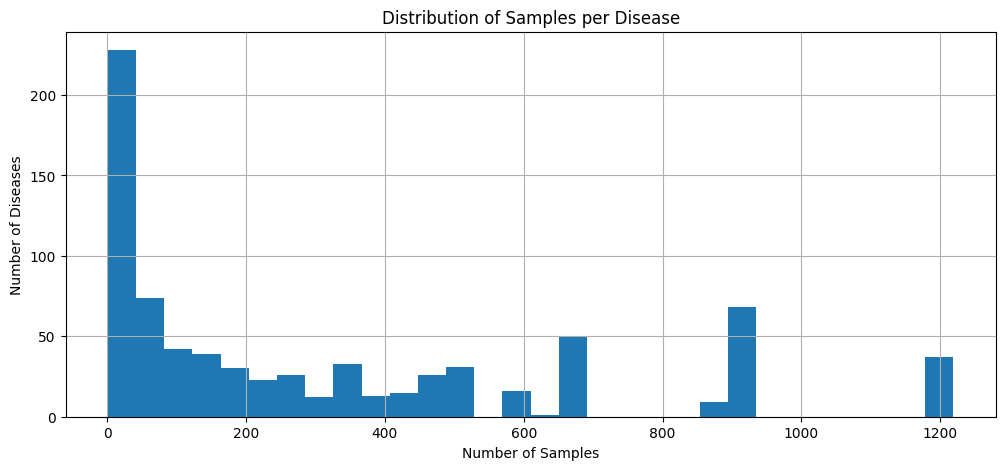

In [21]:
import matplotlib.pyplot as plt

disease_counts = df['diseases'].value_counts()

plt.figure(figsize=(12,5))
plt.hist(disease_counts.values, bins=30)
plt.title("Distribution of Samples per Disease")
plt.xlabel("Number of Samples")
plt.ylabel("Number of Diseases")
plt.grid(True)

plt.show()

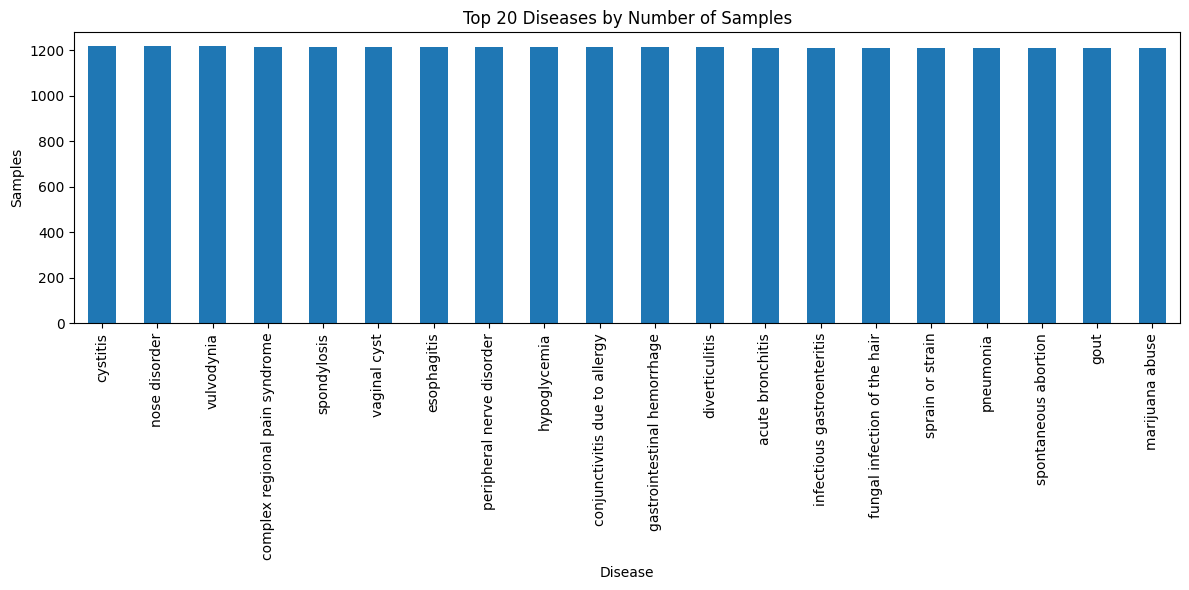

In [22]:
top20 = df['diseases'].value_counts().head(20)

plt.figure(figsize=(12,6))
top20.plot(kind='bar')

plt.title("Top 20 Diseases by Number of Samples")
plt.xlabel("Disease")
plt.ylabel("Samples")

plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

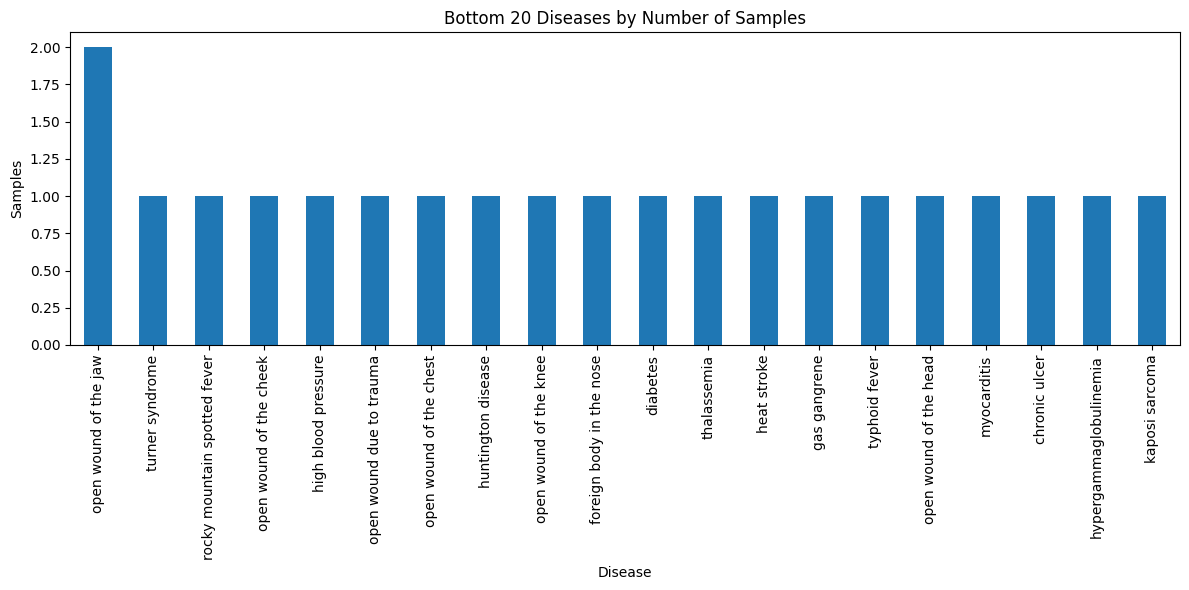

In [23]:
bottom20 = df['diseases'].value_counts().tail(20)

plt.figure(figsize=(12,6))
bottom20.plot(kind='bar')

plt.title("Bottom 20 Diseases by Number of Samples")
plt.xlabel("Disease")
plt.ylabel("Samples")

plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

In [24]:
# Columns ending with .1

dot_one_columns = [col for col in df.columns if col.endswith(".1")]

print(dot_one_columns)
print("Total:", len(dot_one_columns))

['regurgitation.1']
Total: 1


In [25]:
# ============================================================
# Step 24: Compare regurgitation columns
# ============================================================

same_values = (df["regurgitation"] == df["regurgitation.1"]).all()

print("Are both columns exactly identical?", same_values)

Are both columns exactly identical? False


# Final Validation Summary

## Dataset Overview

- Total Records: **246,945**
- Total Features: **377 Symptom Features**
- Target Classes: **773 Diseases**
- Missing Values: **0**
- Duplicate Rows: **57,298**
- Binary Features: **Yes (0/1 Encoded)**

## Validation Findings

- Dataset loaded successfully.
- No missing values were found.
- Binary encoding is consistent across symptom features.
- One feature with `.1` suffix (`regurgitation.1`) exists, but it is **not identical** to `regurgitation`, so both features will be retained for preprocessing.
- Some diseases contain very few samples and will be handled during preprocessing.
- Duplicate rows were identified and will be analyzed during preprocessing.

## Conclusion

The dataset passed the validation phase and is approved for preprocessing and machine learning pipeline development.